## 패키지 선언

In [30]:
import torch
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

## Dataset 선언

In [31]:
# Training dataset 다운로드
mnist_train = dataset.MNIST(root = "./", # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
mnist_test = dataset.MNIST(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

## MNIST 데이터셋 형상 확인

60000
300
Dataset MNIST
    Number of datapoints: 300
    Root location: ./
    Split: Train
    StandardTransform
Transform: ToTensor()
torch.Size([1, 28, 28])
5


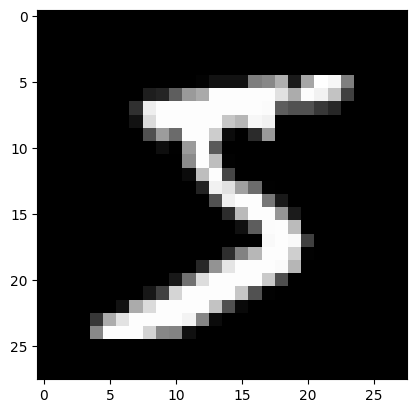

In [32]:
import matplotlib.pyplot as plt
print(len(mnist_train))     # training dataset 개수 확인

mnist_train.data = mnist_train.data[:300] # 이미지 데이터 개수 300으로 설정
mnist_train.targets = mnist_train.targets[:300] # 라벨 데이터 개수 300으로 설정
print(len(mnist_train))
print(mnist_train)

first_data = mnist_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

In [33]:
first_img = first_data[0]
print(first_img.shape)

first_img = first_img.view(-1, 28*28) # 이미지 평탄화 수행 2D -> 1D
print(first_img.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


##MNIST Train Data Rotation 변환

In [34]:
import torchvision.transforms as transform

trans_rotation_left_15 = transform.RandomRotation((-15, -15)) # 반시계방향 15도 로테이션 수행
rotation_data_left_15 = trans_rotation_left_15(mnist_train.data)

trans_rotation_left_30 = transform.RandomRotation((-30, -30)) # 반시계방향 30도 로테이션 수행
rotation_data_left_30 = trans_rotation_left_30(mnist_train.data)

trans_rotation_right_15 = transform.RandomRotation((15, 15)) # 시계 방향 15도 로테이션 수행
rotation_data_right_15 = trans_rotation_right_15(mnist_train.data)

trans_rotation_right_30 = transform.RandomRotation((30, 30)) # 시계 방향 30도 로테이션 수행
rotation_data_right_30 = trans_rotation_right_30(mnist_train.data)

## rotation_data 형태 확인

In [35]:
print(rotation_data_left_15.shape)
print(rotation_data_left_30.shape)
print(rotation_data_right_15.shape)
print(rotation_data_right_30.shape)

torch.Size([300, 28, 28])
torch.Size([300, 28, 28])
torch.Size([300, 28, 28])
torch.Size([300, 28, 28])


## rotation 수행된 데이터 MNIST Train Dataset 에 합치기

In [36]:
mnist_train.data = torch.cat((mnist_train.data, rotation_data_left_15, rotation_data_left_30, rotation_data_right_15, rotation_data_right_30), 0)
mnist_train.data.shape

torch.Size([1500, 28, 28])

## Train Dataset label 늘리기

In [37]:
mnist_train.targets = mnist_train.targets.repeat(5) #같은 Tensor 데이터 5배 증가
mnist_train.targets.shape

torch.Size([1500])

In [38]:
print(mnist_train.targets[0])
print(mnist_train.targets[300])
print(mnist_train.targets[600])
print(mnist_train.targets[900])
print(mnist_train.targets[1200])

tensor(5)
tensor(5)
tensor(5)
tensor(5)
tensor(5)


In [39]:
print(mnist_train.targets[1])
print(mnist_train.targets[301])
print(mnist_train.targets[601])
print(mnist_train.targets[901])
print(mnist_train.targets[1201])

tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)


## Multi Layer Perceptron 모델 정의: 5-layer

In [40]:
class FMLP (nn.Module):
  def __init__(self):
    super(FMLP, self).__init__()
    self.fc1 = nn.Linear(784, 100)
    self.fc2 = nn.Linear(100, 100)
    self.fc3 = nn.Linear(100, 100)
    self.fc4 = nn.Linear(100, 100)
    self.fc5 = nn.Linear(100, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = x.view(-1, 28*28)

    y = self.relu(self.fc1(x))
    y = self.relu(self.fc2(y))
    y = self.relu(self.fc3(y))
    y = self.relu(self.fc4(y))
    y = self.fc5(y)
    return y

## Hyper-parameters 지정

In [41]:
batch_size = 10
learning_rate = 0.1
training_epochs = 100 # 에폭 100으로 설정
loss_function = nn.CrossEntropyLoss()
network = FMLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [42]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 2.285078
Epoch: 2 Loss = 1.824696
Epoch: 3 Loss = 1.058096
Epoch: 4 Loss = 0.744219
Epoch: 5 Loss = 0.545186
Epoch: 6 Loss = 0.328962
Epoch: 7 Loss = 0.264660
Epoch: 8 Loss = 0.232765
Epoch: 9 Loss = 0.155785
Epoch: 10 Loss = 0.119303
Epoch: 11 Loss = 0.059513
Epoch: 12 Loss = 0.100070
Epoch: 13 Loss = 0.064176
Epoch: 14 Loss = 0.011351
Epoch: 15 Loss = 0.005640
Epoch: 16 Loss = 0.002437
Epoch: 17 Loss = 0.001176
Epoch: 18 Loss = 0.000871
Epoch: 19 Loss = 0.000702
Epoch: 20 Loss = 0.000585
Epoch: 21 Loss = 0.000502
Epoch: 22 Loss = 0.000440
Epoch: 23 Loss = 0.000392
Epoch: 24 Loss = 0.000348
Epoch: 25 Loss = 0.000315
Epoch: 26 Loss = 0.000288
Epoch: 27 Loss = 0.000265
Epoch: 28 Loss = 0.000245
Epoch: 29 Loss = 0.000227
Epoch: 30 Loss = 0.000212
Epoch: 31 Loss = 0.000198
Epoch: 32 Loss = 0.000186
Epoch: 33 Loss = 0.000176
Epoch: 34 Loss = 0.000167
Epoch: 35 Loss = 0.000158
Epoch: 36 Loss = 0.000150
Epoch: 37 Loss = 0.000143
Epoch: 38 Loss = 0.000136
Epoch: 39 Loss = 0.00

## Train Data 적용

In [43]:
with torch.no_grad():
  img_test = mnist_train.data.float()
  label_test = mnist_train.targets
  prediction = network(img_test)

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 1.0


##Test Data 적용

In [44]:
with torch.no_grad():
  network.eval() # Network Dropout 비활성
  img_test = mnist_test.data.float()
  label_test = mnist_test.targets

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item()) # overfitting 문제일 경우 정답률 77% 부근   # Batch Normalization으로 해결했을 경우 정답률 80% 부근
  # dropout으로 해결했을 경우 정답률 77% 부근  # Data Augmentation으로 해결했을 경우 정답률 81% 부근

Accuracy: 0.8133999705314636


## Weight parameter 저장하기/불러오기

In [45]:
torch.save(network.state_dict(), "./mlp_mnist.pth")